In [1]:
### 1. Import Libraries and Fetch Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import yfinance as yf
from tensorflow.keras.optimizers import Adam

# Fetching data using yfinance
stock_ticker = 'NVDA'  # Replace with the desired stock ticker
data = yf.Ticker(stock_ticker)
data = data.history(period="5y")
data.reset_index(inplace=True)

In [2]:
### 2. Data Cleaning and Feature Engineering
# Selecting relevant columns
data = data[['Date', 'Close', 'Volume']]

# Calculating simplified indicators
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()
data.dropna(inplace=True)

In [3]:
### 3. Splitting Data into Training and Testing Sets
# Splitting the data
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# Saving to CSV for inspection
train_data.to_csv("Training_Data.csv", index=False)
test_data.to_csv("Testing_Data.csv", index=False)

In [4]:
### 4. Scaling and Preparing Data for LSTM
# Combine training and testing data for consistent scaling
combined_data = pd.concat([train_data, test_data])
sc = MinMaxScaler(feature_range=(0, 1))
combined_scaled = sc.fit_transform(combined_data[['Close', 'EMA_20', 'EMA_50']])

# Separate scaled data back into training and testing sets
scaled_train = combined_scaled[:len(train_data)]
scaled_test = combined_scaled[len(train_data):]

# Debugging scaling
print("Scaled Train Min:", np.min(scaled_train, axis=0))
print("Scaled Train Max:", np.max(scaled_train, axis=0))
print("Scaled Test Min:", np.min(scaled_test, axis=0))
print("Scaled Test Max:", np.max(scaled_test, axis=0))

# Preparing training data
X_train = []
y_train = []
for i in range(60, len(scaled_train)):
    X_train.append(scaled_train[i-60:i])
    y_train.append(scaled_train[i, 0])  # Predicting 'Close' price
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))

Scaled Train Min: [0. 0. 0.]
Scaled Train Max: [0.31600706 0.30670072 0.31063346]
Scaled Test Min: [0.29631814 0.30748796 0.31131321]
Scaled Test Max: [1. 1. 1.]


In [5]:
### 5. Hyperparameter Optimization Logic
# Define hyperparameter search space
lstm_units = [50, 100]
dropout_rates = [0.2, 0.3]
batch_sizes = [16, 32]
learning_rates = [0.001, 0.0005]
epochs = [50, 100]

# Store results
best_loss = float("inf")
best_params = {}

for units in lstm_units:
    for dropout in dropout_rates:
        for batch_size in batch_sizes:
            for lr in learning_rates:
                for epoch in epochs:
                    print(f"Testing configuration: LSTM Units={units}, Dropout={dropout}, Batch Size={batch_size}, Learning Rate={lr}, Epochs={epoch}")

                    # Build model
                    model = Sequential()
                    model.add(LSTM(units=units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
                    model.add(Dropout(dropout))
                    model.add(LSTM(units=units, return_sequences=True))
                    model.add(Dropout(dropout))
                    model.add(LSTM(units=units, return_sequences=True))
                    model.add(Dropout(dropout))
                    model.add(LSTM(units=units))
                    model.add(Dropout(dropout))
                    model.add(Dense(units=1))

                    # Compile model
                    optimizer = Adam(learning_rate=lr)
                    model.compile(optimizer=optimizer, loss='mean_squared_error')

                    # Train model
                    history = model.fit(X_train, y_train, epochs=epoch, batch_size=batch_size, verbose=0)

                    # Evaluate loss
                    final_loss = history.history['loss'][-1]
                    print(f"Final Loss: {final_loss}")

                    # Update best parameters if necessary
                    if final_loss < best_loss:
                        best_loss = final_loss
                        best_params = {
                            'units': units,
                            'dropout': dropout,
                            'batch_size': batch_size,
                            'learning_rate': lr,
                            'epochs': epoch
                        }

print("Best Parameters:", best_params)
print("Best Loss:", best_loss)

Testing configuration: LSTM Units=50, Dropout=0.2, Batch Size=16, Learning Rate=0.001, Epochs=50


/Users/alexanderdagher/Documents/new project/myenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Final Loss: 0.00016564062389079481
Testing configuration: LSTM Units=50, Dropout=0.2, Batch Size=16, Learning Rate=0.001, Epochs=100
Final Loss: 0.00012894698011223227
Testing configuration: LSTM Units=50, Dropout=0.2, Batch Size=16, Learning Rate=0.0005, Epochs=50
Final Loss: 0.0001688492193352431
Testing configuration: LSTM Units=50, Dropout=0.2, Batch Size=16, Learning Rate=0.0005, Epochs=100
Final Loss: 0.00014419943909160793
Testing configuration: LSTM Units=50, Dropout=0.2, Batch Size=32, Learning Rate=0.001, Epochs=50
Final Loss: 0.00018975282728206366
Testing configuration: LSTM Units=50, Dropout=0.2, Batch Size=32, Learning Rate=0.001, Epochs=100
Final Loss: 0.00012221475481055677
Testing configuration: LSTM Units=50, Dropout=0.2, Batch Size=32, Learning Rate=0.0005, Epochs=50
Final Loss: 0.0001984724513022229
Testing configuration: LSTM Units=50, Dropout=0.2, Batch Size=32, Learning Rate=0.0005, Epochs=100
Final Loss: 0.00015621335478499532
Testing configuration: LSTM Units=5

In [6]:
### 6. Preparing Test Data and Making Predictions
# Preparing test data
X_test = []
y_test = test_data['Close'].values[60:]  # Actual 'Close' prices for comparison
for i in range(60, len(scaled_test)):
    X_test.append(scaled_test[i-60:i])
X_test = np.array(X_test, dtype=np.float32)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Predicting stock prices
best_model = Sequential()
best_model.add(LSTM(units=best_params['units'], return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
best_model.add(Dropout(best_params['dropout']))
best_model.add(LSTM(units=best_params['units'], return_sequences=True))
best_model.add(Dropout(best_params['dropout']))
best_model.add(LSTM(units=best_params['units'], return_sequences=True))
best_model.add(Dropout(best_params['dropout']))
best_model.add(LSTM(units=best_params['units']))
best_model.add(Dropout(best_params['dropout']))
best_model.add(Dense(units=1))

optimizer = Adam(learning_rate=best_params['learning_rate'])
best_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Training with best parameters
history = best_model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], verbose=1)

predicted_stock_price = best_model.predict(X_test, batch_size=best_params['batch_size'])
predicted_stock_price_expanded = np.zeros((predicted_stock_price.shape[0], scaled_train.shape[1]))
predicted_stock_price_expanded[:, 0] = predicted_stock_price.flatten()
predicted_stock_price = sc.inverse_transform(predicted_stock_price_expanded)[:, 0]

### Backtesting Logic
# Calculating trend accuracy
trend_real = np.sign(np.diff(y_test))  # Actual trends (1 for up, -1 for down, 0 for no change)
trend_predicted = np.sign(np.diff(predicted_stock_price))  # Predicted trends
trend_accuracy = np.mean(trend_real == trend_predicted) * 100

# Calculating price accuracy (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - predicted_stock_price) / y_test)) * 100

# Backtesting summary
overall_accuracy = 100 - mape  # Overall prediction accuracy
print("Trend Accuracy: {:.2f}%".format(trend_accuracy))
print("Mean Absolute Percentage Error (MAPE): {:.2f}%".format(mape))
print("Overall Accuracy Score: {:.2f}%".format(overall_accuracy))

# Saving backtesting results
backtest_results = pd.DataFrame({
    'Date': test_data['Date'].iloc[61:].values,  # Adjusted for diff()
    'Real Price': y_test[1:],
    'Predicted Price': predicted_stock_price[1:]
})
backtest_results.to_csv("Backtesting_Results.csv", index=False)

### Future Prediction Logic (20 Days Ahead)
# Starting with the last 60 days of the test set
future_input = scaled_test[-60:]
future_predictions = []

for _ in range(20):
    # Reshape input to match LSTM expected shape
    future_input = future_input.reshape(1, future_input.shape[0], future_input.shape[1])
    future_pred = best_model.predict(future_input)

    # Append the prediction to the results
    future_predictions.append(future_pred[0, 0])

    # Update the input by appending the prediction and removing the oldest step
    next_step = np.zeros((1, scaled_train.shape[1]))
    next_step[0, 0] = future_pred[0, 0]
    future_input = np.vstack([future_input[0, 1:, :], next_step])

# Rescale predictions back to original range
future_predictions = sc.inverse_transform(
    np.pad(np.array(future_predictions).reshape(-1, 1), ((0, 0), (0, scaled_train.shape[1] - 1)), constant_values=0)
)[:, 0]

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0042
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 5.1893e-04
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 3.8594e-04
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 4.9004e-04
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 3.9601e-04
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 3.9751e-04
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 3.4921e-04
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 4.5247e-04
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.8788e-04
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 3.4026e-04
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.6429e-04
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.3796e-04
Epoch 13/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 2.5945e-04
Epoch 14/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2.5741e-04
Epoch

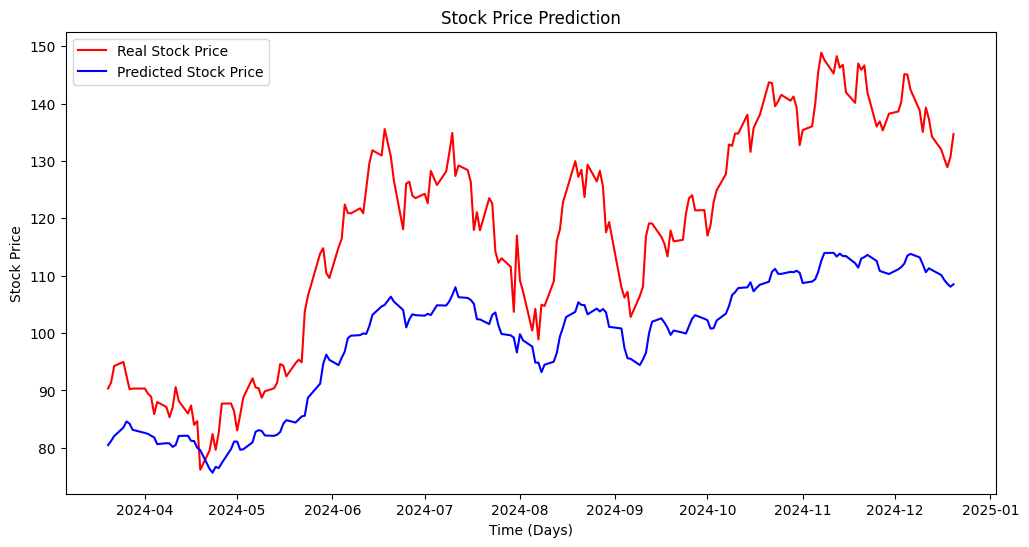

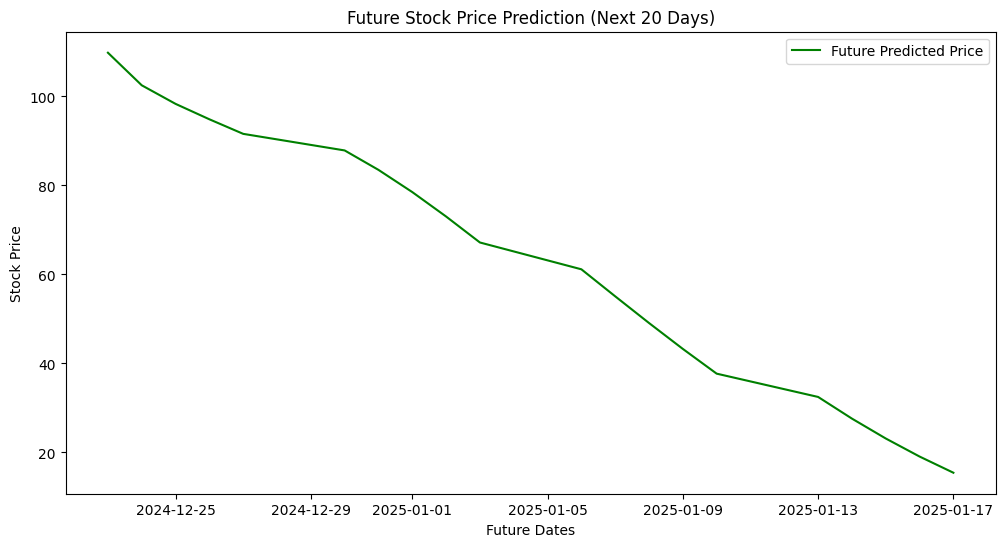

In [7]:
### 7. Visualizing Results and Saving Predictions
# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'].iloc[60:], y_test, color='red', label='Real Stock Price')
plt.plot(test_data['Date'].iloc[60:], predicted_stock_price, color='blue', label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Saving predictions to CSV
output_test = pd.DataFrame({
    'Date': test_data['Date'].iloc[60:].values,
    'Real Price': y_test,
    'Predicted Price': predicted_stock_price.flatten()
})
output_test.to_csv("Fitted_Data_Output.csv", index=False)

# Saving future predictions to CSV
future_dates = pd.date_range(start=test_data['Date'].iloc[-1], periods=21, freq='B')[1:]
future_output = pd.DataFrame({
    'Date': future_dates,
    'Future Predicted Price': future_predictions
})
future_output.to_csv("Future_Predictions.csv", index=False)

# Plotting future predictions
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions, color='green', label='Future Predicted Price')
plt.title('Future Stock Price Prediction (Next 20 Days)')
plt.xlabel('Future Dates')
plt.ylabel('Stock Price')
plt.legend()
plt.show()